# LINCS1000 Analysis

The following analysis of one or more LINCS1000 transcriptomic datasets is as follows:

- Isolating a cell line of interest
- Identifying compounds of interest
- Overlaying timepoint transcriptomics data from compounds onto the human PPI network
    - Optionally altering edge number based on co-expression
- Embedding resulting graphs into the same embedding space
- Calculating differences between graph embeddings
- Visualising similarities/differences between transcriptomic signatures/graph embeddings

# Packages

In [209]:
#from karateclub import Graph2Vec
import inspect
import itertools
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3, venn3_circles
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import random
import seaborn as sns
import tarfile
from typing import Union, get_args
from upsetplot import UpSet, from_indicators, from_memberships
import warnings

# Directories

In [210]:
DATAFRAME = "D:/DDesktop/_code/canada/lincs_analysis/dataframes/"
GRAPH = "D:/DDesktop/_code/canada/lincs_analysis/graphs/"
GRAPH_BASE = "D:/DDesktop/_code/canada/lincs_analysis/graphs/base/"
GRAPH_PERTURBAGEN = "D:/DDesktop/_code/canada/lincs_analysis/graphs/perturbagen/"
SIGNATURE = "D:/DDesktop/_code/canada/lincs_analysis/lincs_signatures/"
STRING = "D:/DDesktop/_code/canada/lincs_analysis/string/"
PLOT = "D:/DDesktop/_code/canada/lincs_analysis/plots/"

# Functions

## General

In [211]:
def func_param_typecheck(function, *args, **kwargs) -> None:
    '''
    Checks the types of parameters for a given function based on parameter annotations.

    ### Parameters

    `function`: Any

    - The function whose parameters are being checked.

    `*args`: tuple

    - Tuple of positional parameters for given function, can be any type.

    `**kwargs` : dict

    - Dictionary of keyword arguments passed to the given function, where keys are strings and values are any type.

    ### Raises

    `TypeError`

    - Error raised if any parameter does not match its annotated type
    '''

    ## FUNCTION

    # Get function signature
    function_signature = inspect.signature(function)
    # Get function arguments
    function_arguments = function_signature.bind(*args, **kwargs)

    # Iterate through function parameters and input data types
    for parameter_name, parameter_type in function_arguments.arguments.items():
        # Get expected parameter type from annotation
        expected_type = function_signature.parameters[parameter_name].annotation
        # Check the expected type isn't empty
        if expected_type != inspect.Parameter.empty:
            # Check if parameter annotations are in a Union
            if hasattr(expected_type, '__origin__') and expected_type.__origin__ is Union:
                # Type check
                if not isinstance(parameter_type, get_args(expected_type)):
                    # Extract list of allowed types
                    allowed_types = ', '.join(etype.__name__ for etype in get_args(expected_type))
                    # Raise error
                    raise TypeError(f'Parameter \'{parameter_name}\' must be one of types: \'{allowed_types}\', ' 
                                    f'but got \'{type(parameter_type).__name__}\'')
            # Else type check single annotated type
            elif not isinstance(parameter_type, expected_type):
                # Raise error
                raise TypeError(f'Parameter \'{parameter_name}\' must be of type \'{expected_type.__name__}\', '
                                f'but got \'{type(parameter_type).__name__}\'')

## Template

In [212]:
# def function(var: type, report: bool = False) -> type:
#     '''
#     Function summary.

#     ### Parameters

#     `dataframe`: pd.DataFrame

#     > The pandas DataFrame to be edited.

#     `parameter`: type

#     > parameter description

#     ### Returns

#     `df`: pd.DataFrame

#     > Edited pandas DataFrame.

#     `variable`: type

#     > return description
#     '''

#     ## CHECK

#     # Type
#     # func_param_typecheck(func, p1, p2, ..., report)
    
#     # Other

#     ## FUNCTION

#     # Create DataFrame copy
#     # df = dataframe.copy()
#     # Create graph copy
#     # g = graph.copy()

#     ## REPORT

#     if report == True:
#         # Statistics
#         # Print
#         print('>> function')
#         print('')
#         print()

#     return

## Functions

In [231]:
def graph_save(graph: nx.Graph, graph_name: str, path: str = os.getcwd(), graphml: bool = False, report: bool = False) -> None:
    '''
    Saves a NetworkX graph object to specified location using the pickle package OR as a .gml file for downstream analysis.

    ### Parameters

    `graph`: nx.Graph

    > NetworkX graph object to be saved.

    `graph_name`: str

    > Name for saved file.

    `path`: str (default = current working directory)

    > Save location.

    ### Returns

    Pickled graph object
    '''

    ## CHECK

    # Type
    func_param_typecheck(graph_save, graph, graph_name, path, graphml, report)

    ## FUNCTION

    # Check graphml parameter
    if graphml == False:
        # Pickle graph
        with open(f'{path}/{graph_name}.pkl', 'wb') as f:
            pickle.dump(graph, f)
    else:
        # Save graph as .gml file
        nx.write_graphml(graph, path = f'{path}/{graph_name}.gml')

    ## REPORT

    if report == True:
        # Statistics
        # Print
        print('>> graph_save')
        if graphml == False:
            print(f'NetworkX graph object saved to {path}/{graph_name}.pkl')
        else:
            print(f'NetworkX graph object saved to {path}/{graph_name}.gml')
        print()

def graph_load(path: str, graphml: bool = False, report: bool = False) -> nx.Graph:
    '''
    Loads a pickled NetworkX graph object.

    ### Parameters

    `path`: str

    > Location of the pickled graph file.

    ### Returns

    `graph`: nx.Graph

    > NetworkX graph object.
    '''

    ## CHECK

    # Type
    func_param_typecheck(graph_load, path, graphml, report)

    ## FUNCTION

    # Check graphml parameter
    if graphml == False:
        with open(f'{path}', 'rb') as f:
            graph = pickle.load(f)
    else:
        graph = nx.read_graphml(path)
        graph = nx.relabel_nodes(graph, lambda x: int(x))

    ## REPORT

    if report == True:
        # Statistics
        num_nodes = graph.number_of_nodes()
        num_edges = graph.number_of_edges()
        # Print
        print('>> graph_load')
        if graphml == False:
            print(f'Pickled NetworkX graph object with {num_nodes:,} nodes and {num_edges:,} edges loaded from {path}')
        else:
            print(f'GraphML NetworkX graph object with {num_nodes:,} nodes and {num_edges:,} edges loaded from {path}')
        print()

    return graph

def graph_visualise_network(graph: nx.Graph, pos: dict, cell_line: str, drug: str, dosage: str, timepoint: int, figx: Union[float, int] = 10, figy: Union[float, int] = 10, cmap: str = 'seismic', vmin: Union[float, int] = 0.1, vmax: Union[float, int] = 0.1, edge_factor: Union[float, int] = 500, edge_colour: str = 'black', edge_alpha: float = 0.5, colourbar : bool = True) -> Figure:
    '''
    Plots a NetworkX graph object as a standard network. Must be passed a graph with nested cell line, drug, dosage and timepoint node attributes. Allows for some nodes to lack node attributes.

    ### Parameters

    `graph`: nx.Graph

    > NetworkX graph object to be visualised.

    `pos`: dict

    > Positional data for graph object.

    `cell_line`: str

    > Cell line used to filter graph node attributes e.g. 'HT29'

    `drug`: str

    > Drug name used to filter graph node attributes e.g. 'ibuprofen'

    `dosage`: str

    > Dosage value used to filter graph node attributes, in uM e.g. '10'

    `timepoint`: int

    > Timepoint value used to filter graph node attributes e.g. 6

    `figx`: float, int (default = 10)

    > X-axis size of plot.

    `figy`: float, int (default = 10)

    > Y-axis size of plot.

    `cmap`: str (default = 'seismic')

    > Colourmap used to represent CD-coefficient node attribute value in plot. Diverging colourmap is recommended.    

    `vmin`: float, int (default = -0.1)

    > Minimum value for `colourmap`

    `vmax`: float, int (default = 0.1)

    > Maximum value for `colourmap`

    `edge_factor`: float, int (default = 500)

    > Factor by which the edge weights are divided for visualisation. Higher value is recommended if using combined score directly from STRING data.

    `edge_colour`: str (default = 'black')

    > Colour for plotted edges.

    `edge_alpha`: float (default = 0.5)

    > Alpha value for plotted edges.

    `colourbar`: bool (default = True)

    > Adds a colourbar to the plot.

    ### Returns

    A NetworkX visualisation of a graph, overlayed with LINCS1000 CD-coefficient values from a defined filter of attributes.

    '''

    ## CHECK

    # Type
    func_param_typecheck(graph_visualise_network, graph, pos, cell_line, drug, dosage, timepoint, figx, figy, cmap, vmin, vmax, edge_factor, edge_colour, edge_alpha, colourbar)

    ## FUNCTION
    
    # Initialise lists
    nodes_with_vals = []
    nodes_without_vals = []
    values = [] 
    edge_weights = [graph[u][v]['weight']/edge_factor for u, v in graph.edges()]

    # Iterate through nodes
    for node in graph.nodes:
        # Filter for all attributes
        filter_value = (graph.nodes[node]
                        .get(cell_line, {})
                        .get(drug, {})
                        .get(dosage, {})
                        .get(timepoint))

        # Check filter_value
        if filter_value is not None:
            # Append node to list
            nodes_with_vals.append(node)
            # Append value to list
            values.append(filter_value)
        else:
            # Append node to list
            nodes_without_vals.append(node)

    ## PLOT

    # Initialise plot
    plt.figure(figsize = (figx, figy))
    
    # Draw edges
    plot_edges = nx.draw_networkx_edges(graph, pos = pos, width = edge_weights, edge_color = edge_colour, alpha = edge_alpha)
    # Draw nodes without values
    plot_nodes_without = nx.draw_networkx_nodes(graph, pos = pos, nodelist = nodes_without_vals, node_color = 'lightgrey', edgecolors = 'black')
    # Draw nodes with values
    plot_nodes_with = nx.draw_networkx_nodes(graph, pos = pos, nodelist = nodes_with_vals, node_color = values, cmap = 'seismic_r', vmin = vmin, vmax = vmax, edgecolors = 'black')

    # Check colorbar parameter
    if colourbar == True:
        # Generate colorbar
        cbar = plt.colorbar(plot_nodes_with, label = 'CD-coefficient', orientation = 'horizontal', fraction= 0.02)
        # Set position
        cbar.ax.set_position([0.75, 0.85, 0.15, 0.02])

    # Remove border
    plt.box(False)

    # Define title
    plt.title(f'Human STRING PPI network w/ CD-coefficient values from {drug}-treated {cell_line} cells ({dosage}uM) at {timepoint}h')
    # Show plot
    plt.show()

# LINCS Phase 1

The following section applies to the full [LINCS Phase 1](https://lincsportal.ccs.miami.edu/datasets/view/LDS-1191) dataset ([Data Level 5](https://lincsportal.ccs.miami.edu/datasets/view/LDS-1191)).

- This data was downloaded as a `.tar.gz` file
- Extracted to the `lincs_tar_extracted` directory as a `gctx.gz` file with associated metadata
- The main data file was extracted to `LDS-1481_1.0.gtx`
- Converting this to a `.csv` file was computationally taxing and took over 2 hours, and so was cancelled

In [214]:
# # Define path to zipped file
# tar_path = "D:\DDesktop\_code\canada\lincs_analysis\LDS-1481_1.0.tar.gz"
# # Extract LDS-1481_1.0.tar.gz
# with tarfile.open(tar_path, "r:gz") as tar:
#     # Extract to folder
#     tar.extractall("lincs_tar_extracted")

In [215]:
# import gzip
# import shutil

# # Define input and output file paths
# gz_file = "D:/DDesktop/_code/canada/lincs_analysis/lincs_tar_extracted/LDS-1481/Data/GSE92742_Broad_LINCS_Level5_COMPZ.MODZ_n473647x12328.gctx.gz"
# output_file = "data.gctx"

# # Extract gctx file
# with gzip.open(gz_file, "rb") as file_in:
#     with open(output_file, "wb") as file_out:
#         shutil.copyfileobj(file_in, file_out)

In [216]:
# from cmapPy.pandasGEXpress.parse import parse

# # Load data.gctx
# data = parse("data.gctx")

# # Convert to DataFrame
# df = data.data_df

# # Save to csv
# df.to_csv("data.csv", index = True)

# # Show data
# df.head()

# Graph Comparison

The human PPI network was downloaded from STRINGdb

## PPI

In this section, a foundational human network is generated from the STRINGdb data, using networkx

### `string_edgelist`

In [217]:
# Import data
string_edgelist = pd.read_csv(STRING + '9606.protein.physical.links.full.v12.0.txt.gz', compression = 'gzip', sep = ' ')
# Show data
string_edgelist.head()

,protein1,protein2,homology,experiments,experiments_transferred,database,database_transferred,textmining,textmining_transferred,combined_score
0,9606.ENSP00000000233,9606.ENSP00000257770,0,312,0,0,0,0,0,311
1,9606.ENSP00000000233,9606.ENSP00000226004,0,162,0,0,0,0,0,161
2,9606.ENSP00000000233,9606.ENSP00000434442,0,0,0,500,0,0,0,499
3,9606.ENSP00000000233,9606.ENSP00000262455,0,531,0,0,0,0,0,531
4,9606.ENSP00000000233,9606.ENSP00000303145,0,0,0,500,0,0,0,499


### `string_info`

In [218]:
# Import protein info
string_info = pd.read_csv(STRING + '9606.protein.info.v12.0.txt.gz', compression = 'gzip', sep = '\t')
# Show data
string_info.head()

,#string_protein_id,preferred_name,protein_size,annotation
0,9606.ENSP00000000233,ARF5,180,ADP-ribosylation factor 5; GTP-binding protein...
1,9606.ENSP00000000412,M6PR,277,Cation-dependent mannose-6-phosphate receptor;...
2,9606.ENSP00000001008,FKBP4,459,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
3,9606.ENSP00000001146,CYP26B1,512,Cytochrome P450 26B1; Involved in the metaboli...
4,9606.ENSP00000002125,NDUFAF7,441,"Protein arginine methyltransferase NDUFAF7, mi..."


### `df_string`

In [219]:
warnings.filterwarnings('ignore')

## GENERATE DF_STRING
# Generate dataframe copy
df_string = string_edgelist.copy(deep = True)
# Drop columns
df_string = df_string[['protein1', 'protein2', 'combined_score']]

# Rename columns for first merge
string_info.rename(columns = {'#string_protein_id' : 'protein1'}, inplace = True)
# Merge dataframes
df_string = pd.merge(df_string, string_info[['protein1', 'preferred_name', 'annotation']], how = 'left', on = 'protein1')

# Rename column for second merge
string_info.rename(columns = {'protein1' : 'protein2'}, inplace = True)
# Merge dataframes
df_string = pd.merge(df_string, string_info[['protein2', 'preferred_name', 'annotation']], how = 'left', on = 'protein2')

# Format string_info dataframe
string_info.rename(columns = {'protein2' : '#string_protein_id'}, inplace = True)

# Rename columns
old_names = df_string.columns
new_names = ['source_id', 'target_id', 'weight', 'source_name', 'source_annot', 'target_name', 'target_annot']
for old, new in zip(old_names, new_names):
    df_string.rename(columns = {old : new}, inplace = True)

# Format df
for column in ['source_id', 'target_id']:
    df_string[column] = df_string[column].str.replace('9606.', '')

# Define column order
column_order = ['source_name', 'target_name', 'source_id', 'target_id', 'source_annot', 'target_annot', 'weight']
df_string = df_string[column_order]

# Save data
df_string.to_csv(DATAFRAME + 'df_string.csv', index = False)

# Show data
df_string.head()

,source_name,target_name,source_id,target_id,source_annot,target_annot,weight
0,ARF5,NT5E,ENSP00000000233,ENSP00000257770,ADP-ribosylation factor 5; GTP-binding protein...,5'-nucleotidase; Hydrolyzes extracellular nucl...,311
1,ARF5,DUSP3,ENSP00000000233,ENSP00000226004,ADP-ribosylation factor 5; GTP-binding protein...,Dual specificity protein phosphatase 3; Shows ...,161
2,ARF5,ARFGAP2,ENSP00000000233,ENSP00000434442,ADP-ribosylation factor 5; GTP-binding protein...,ADP-ribosylation factor GTPase-activating prot...,499
3,ARF5,ERP44,ENSP00000000233,ENSP00000262455,ADP-ribosylation factor 5; GTP-binding protein...,Endoplasmic reticulum resident protein 44; Med...,531
4,ARF5,TMED10,ENSP00000000233,ENSP00000303145,ADP-ribosylation factor 5; GTP-binding protein...,Transmembrane emp24 domain-containing protein ...,499


## Transcriptomics

### `df_signature`

In [220]:
df_signature = pd.DataFrame()

# Iterate through files in SIGNATURE
for file in os.listdir(SIGNATURE):
    
    # Get filename
    filename = file.split('.tsv')[0]
    # Get file information
    cell_line = filename.split('_')[4]
    dosage = filename.split('_')[8]
    drug = filename.split('_')[7]
    timepoint = filename.split('_')[5]

    # Import data
    df = pd.read_csv(SIGNATURE + file, sep = '\t')
    # Add columns
    for column_name, column_value in zip(['cell_line', 'dosage', 'drug', 'timepoint'], [cell_line, dosage, drug, timepoint]):
        df[column_name] = column_value
    
    # Append dataframe
    df_signature = pd.concat([df_signature, df], ignore_index = True)

# Format df_signature
df_signature.rename(columns = {'symbol' : 'node_name', 'CD-coefficient' : 'dexp'}, inplace = True)
df_signature['timepoint'] = df_signature['timepoint'].str.replace('H', '')
df_signature['timepoint'] = df_signature['timepoint'].astype(int)
df_signature['dosage'] = df_signature['dosage'].str.replace('uM', '')

# Save data
df_signature.to_csv(DATAFRAME + 'df_signature.csv', index = False)

# Show data
df_signature.head()

,node_name,dexp,cell_line,dosage,drug,timepoint
0,A1CF,0.009130,HT29,10,ibuprofen,24
1,A2M,0.010224,HT29,10,ibuprofen,24
2,A4GALT,0.001034,HT29,10,ibuprofen,24
3,A4GNT,-0.002264,HT29,10,ibuprofen,24
4,AAAS,-0.000051,HT29,10,ibuprofen,24


## Indexing

In [221]:
# Import data
df_string = pd.read_csv(DATAFRAME + 'df_string.csv')
df_signature = pd.read_csv(DATAFRAME + 'df_signature.csv')

## DEFINE INDEX NUMBERS
# Node names in df_string
list_nodes_string = list(pd.unique(df_string[['source_name', 'target_name']].values.ravel('K')))
print(f'{len(list_nodes_string)} unique node names in df_string')
# Node names in df_signature
list_nodes_signature = list(pd.unique(df_signature['node_name']))
print(f'{len(list_nodes_signature)} unique node names in df_signature')

# Combine lists
list_nodes = list_nodes_string + list_nodes_signature
# Get unique values
list_nodes = list(set(list_nodes))
print(f'{len(list_nodes)} unique nodes found between both datasets')

# Convert to dataframe
df_index = pd.DataFrame(list_nodes, columns = ['node_name'])
# Reset index
df_index.reset_index(inplace = True)
# Rename columns
df_index.rename(columns = {'index' : 'node_index'}, inplace = True)
# Format dtypes
df_index['node_index'] = df_index['node_index'].astype(int)
# Save data
df_index.to_csv(DATAFRAME + 'df_index.csv', index = False)

## MERGING
# Merge with df_signature
df_signature = pd.merge(df_signature, df_index, how = 'left', on = 'node_name')
# Format dtypes
df_signature['node_index'] = df_signature['node_index'].astype(int)

# Rename columns for df_string merge
df_index.rename(columns = {'node_name' : 'source_name'}, inplace = True)
# First merge
df_string = pd.merge(df_string, df_index, how = 'left', on = 'source_name')
# Rename columns
df_index.rename(columns = {'source_name' : 'target_name'}, inplace = True)
# Second merge
df_string = pd.merge(df_string, df_index, how = 'left', on = 'target_name')
# Format df_string
df_string.rename(columns = {'node_index_x' : 'source_index', 'node_index_y' : 'target_index'}, inplace = True)
df_string['source_index'] = df_string['source_index'].astype(int)
df_string['target_index'] = df_string['target_index'].astype(int)
# Return df_index
df_index.rename(columns = {'target_name' : 'node_name'}, inplace = True)

# Save data
df_string.to_csv(DATAFRAME + 'df_string.csv', index = False)
df_signature.to_csv(DATAFRAME + 'df_signature.csv', index = False)

18767 unique node names in df_string
12327 unique node names in df_signature
19138 unique nodes found between both datasets


In [222]:
df_string.head()

,source_name,target_name,source_id,target_id,source_annot,target_annot,weight,source_index,target_index
0,ARF5,NT5E,ENSP00000000233,ENSP00000257770,ADP-ribosylation factor 5; GTP-binding protein...,5'-nucleotidase; Hydrolyzes extracellular nucl...,311,10145,15848
1,ARF5,DUSP3,ENSP00000000233,ENSP00000226004,ADP-ribosylation factor 5; GTP-binding protein...,Dual specificity protein phosphatase 3; Shows ...,161,10145,16247
2,ARF5,ARFGAP2,ENSP00000000233,ENSP00000434442,ADP-ribosylation factor 5; GTP-binding protein...,ADP-ribosylation factor GTPase-activating prot...,499,10145,4656
3,ARF5,ERP44,ENSP00000000233,ENSP00000262455,ADP-ribosylation factor 5; GTP-binding protein...,Endoplasmic reticulum resident protein 44; Med...,531,10145,18743
4,ARF5,TMED10,ENSP00000000233,ENSP00000303145,ADP-ribosylation factor 5; GTP-binding protein...,Transmembrane emp24 domain-containing protein ...,499,10145,2587


In [223]:
df_signature.head()

,node_name,dexp,cell_line,dosage,drug,timepoint,node_index
0,A1CF,0.009130,HT29,10,ibuprofen,24,2054
1,A2M,0.010224,HT29,10,ibuprofen,24,14355
2,A4GALT,0.001034,HT29,10,ibuprofen,24,6981
3,A4GNT,-0.002264,HT29,10,ibuprofen,24,14967
4,AAAS,-0.000051,HT29,10,ibuprofen,24,13709


## `graph_base`

### Graph Object

In [224]:
# Import data
df_string = pd.read_csv(DATAFRAME + 'df_string.csv', dtype = {'source_index' : int, 'target_index' : int})
# Force dtypes
df_string["source_index"] = df_string["source_index"].astype(int)
df_string["target_index"] = df_string["target_index"].astype(int)

# Generate graph from edgelist
graph_base = nx.from_pandas_edgelist(df_string[['source_index', 'target_index', 'weight']], source = 'source_index', target = 'target_index', edge_attr = 'weight')

In [226]:
print(type(next(iter(graph_base.nodes))))  # Check type of a node label

<class 'int'>


### Save

In [227]:
# Save graph
graph_save(graph_base, graph_name = 'graph_base', path = 'D:/DDesktop/_code/canada/lincs_analysis/graphs/base', graphml = True, report = True)

>> graph_save
NetworkX graph object saved to D:/DDesktop/_code/canada/lincs_analysis/graphs/base/graph_base.gml



# Graph Embedding

## Perturbagen Graphs

In [232]:
# Load base graph
graph_base = graph_load(GRAPH_BASE + 'graph_base.gml', graphml = True, report = True)

# Define lists
list_cells = list(pd.unique(df_signature['cell_line'])) 
list_drugs = list(pd.unique(df_signature['drug'])) 
list_doses = list(pd.unique(df_signature['dosage'])) 
list_times = list(pd.unique(df_signature['timepoint'])) 

print('Combination lists defined')
print()
print('Defining combination-specific signal graphs...')

# Iterate through combinations of cell line, drug, dosage, timepoint in `df_signature`
for cell_line, drug, dosage, timepoint in itertools.product(list_cells, list_drugs, list_doses, list_times):

    print(f'    {cell_line}      {drug}      {dosage}      {timepoint}')

    # Slice `df_signature` using the variables
    slice_signature = df_signature[(df_signature['cell_line'] == cell_line) & 
                                   (df_signature['drug'] == drug) & 
                                   (df_signature['dosage'] == dosage) & 
                                   (df_signature['timepoint'] == timepoint)]
    
    # For dtypes
    slice_signature['node_index'] = slice_signature['node_index'].astype(int)
    
    # Set `node_id` as slice_signature index
    slice_signature.set_index('node_index', inplace = True)

    # Drop unneeded columns
    slice_signature = slice_signature[['dexp']]

    # Copy graph_base
    slice_graph = graph_base.copy()
    # Set `dexp` value as node attribute
    nx.set_node_attributes(slice_graph, slice_signature['dexp'].to_dict(), name = 'dexp')
    # Iterate through nodes
    for node in slice_graph.nodes():
        # Check for those without `dexp` attribute
        if 'dexp' not in slice_graph.nodes[node]:
            # Provide 0 as default value
            slice_graph.nodes[node]['dexp'] = 0
    
    # Save graph in GRAPH_PERTURBAGEN
    graph_save(slice_graph, path = GRAPH_PERTURBAGEN, graph_name = f'{cell_line}_{drug}_{dosage}uM_{timepoint}', graphml = True)
    
    print('    Saved')
    print(type(next(iter(slice_graph.nodes))))
    print()

>> graph_load
GraphML NetworkX graph object with 18,767 nodes and 738,805 edges loaded from D:/DDesktop/_code/canada/lincs_analysis/graphs/base/graph_base.gml

Combination lists defined

Defining combination-specific signal graphs...
    HT29      ibuprofen      10      24
    Saved
<class 'int'>

    HT29      ibuprofen      10      6
    Saved
<class 'int'>

    HT29      indoprofen      10      24
    Saved
<class 'int'>

    HT29      indoprofen      10      6
    Saved
<class 'int'>

    HT29      rifaximin      10      24
    Saved
<class 'int'>

    HT29      rifaximin      10      6
    Saved
<class 'int'>

    HT29      mefloquine      10      24
    Saved
<class 'int'>

    HT29      mefloquine      10      6
    Saved
<class 'int'>



In [234]:
slice_graph.nodes(data = True)

NodeDataView({10145: {'dexp': 0.00632626}, 15848: {'dexp': -0.00195433}, 16247: {'dexp': 0.00607837}, 4656: {'dexp': 0.00470253}, 18743: {'dexp': 0.01291808}, 2587: {'dexp': 0.00457014}, 1792: {'dexp': -0.00228042}, 9659: {'dexp': 0.00483158}, 5249: {'dexp': 0}, 18236: {'dexp': -0.00655507}, 10151: {'dexp': -0.00019942}, 10082: {'dexp': -0.00756267}, 17911: {'dexp': 0.01142915}, 13440: {'dexp': -0.01311583}, 7485: {'dexp': -0.00093212}, 8798: {'dexp': 0.00043078}, 8484: {'dexp': -0.00149495}, 7795: {'dexp': -0.01022483}, 8003: {'dexp': -0.00614425}, 13448: {'dexp': 0}, 12286: {'dexp': -0.0004376}, 10281: {'dexp': 0}, 6462: {'dexp': 0}, 16732: {'dexp': 0.00226512}, 6811: {'dexp': 0.00401838}, 11092: {'dexp': -0.00040698}, 18086: {'dexp': -0.00215672}, 16763: {'dexp': -0.01424728}, 9044: {'dexp': 0.01297933}, 12424: {'dexp': -0.01082869}, 18030: {'dexp': 0.00247989}, 12992: {'dexp': -0.00140505}, 14509: {'dexp': -0.01738905}, 15785: {'dexp': 0.00204403}, 5971: {'dexp': 0}, 2681: {'dexp':

## Nested Node Attributes

In [ ]:
# Iterate through `df_signature` and assign nested node attributes to `graph_base`
for _, row in df_signature.iterrows():
    
    # Define values
    node = row['node_id']
    cell_line = row['cell_line']
    drug = row['drug']
    dosage = row['dosage']
    timepoint = row['timepoint']
    value = row['dexp']

    # Check if node is in graph
    if node in graph_base.nodes:
        # Check if cell_line exists in node attributes
        if cell_line not in graph_base.nodes[node]:
            graph_base.nodes[node][cell_line] = {}
        # Check if drug exists in node attributes
        if drug not in graph_base.nodes[node][cell_line]:
            graph_base.nodes[node][cell_line][drug] = {}
        # Check if dosage exists in node attributes
        if dosage not in graph_base.nodes[node][cell_line][drug]:
            graph_base.nodes[node][cell_line][drug][dosage] = {}

        # Add/update nested timepoint value
        graph_base.nodes[node][cell_line][drug][dosage][timepoint] = value

# Visualisation

### Test Graph

In [18]:
# Select a random node from the graph
random_node = random.choice(list(graph_base.nodes))

# Generate a 2-step ego graph for the selected node
ego_graph = nx.ego_graph(graph_base, 'REL', radius=1)

# Generate positional data
ego_pos = nx.kamada_kawai_layout(ego_graph)

# Check node
print(f'{random_node} ego_graph')

SSX1 ego_graph


In [60]:
ego_graph2 = nx.ego_graph(graph_base, 'REL', radius=2)

# Generate positional data
ego_pos2 = nx.spring_layout(ego_graph2, k = 0.2)

In [ ]:
graph_pos = nx.spring_layout(graph_base)

### Network

In [235]:
graph_visualise_network(graph = ego_graph2, pos = ego_pos2, cell_line = 'HT29', drug = 'ibuprofen', dosage = '10', timepoint = 24, vmin = -0.07, vmax = 0.07, figx = 15, figy = 15)

NameError: name 'ego_graph2' is not defined

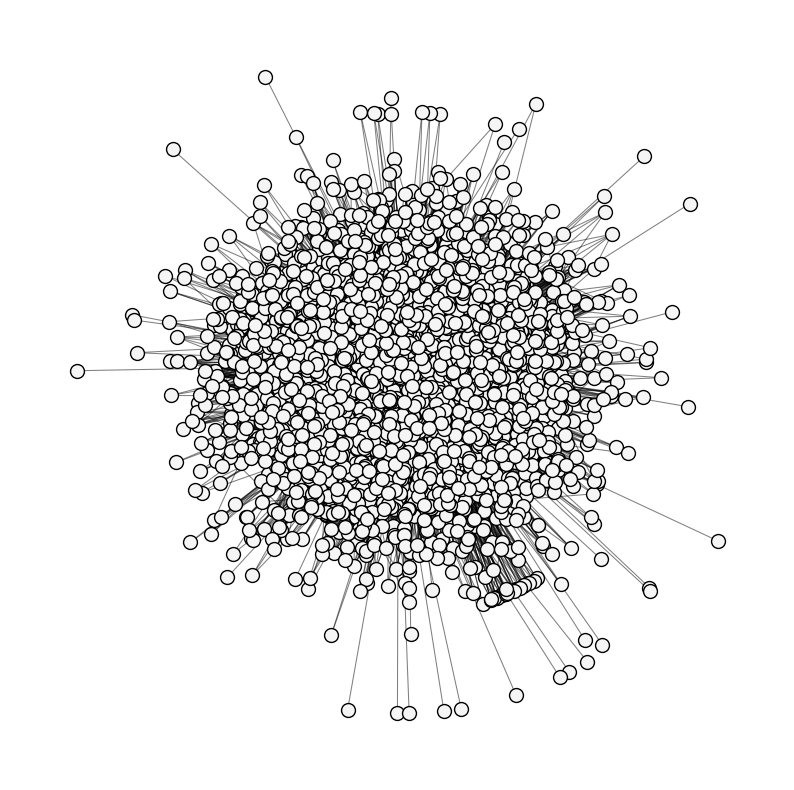

In [75]:
plt.figure(figsize = (10,10))
nx.draw_networkx_edges(ego_graph2, ego_pos2, edge_color = 'black', width = 0.75, alpha = 0.5)
nx.draw_networkx_nodes(ego_graph2, ego_pos2, node_color = 'whitesmoke', node_size = 100, edgecolors = 'black', alpha = 1)
# Remove border
plt.box(False)

### Hex

This function needs `extent_vals` parameter and `count_min/max` parameters for colouring. Also a horizontal colourbar per column to show count min/max value and colour.

In [ ]:
def graph_visualise_hex(graph, pos, cell_line, drug, dosage, timepoint, gridsize: int = 20):
    '''
    Visualises a given network as 2 separate hex distribution plots
    '''

    # Convert pos to dataframe
    node_coords = pd.DataFrame(pos).T
    node_coords.columns = ['x', 'y']

    # Define nodes with attributes
    attr_nodes = attr_nodes = [node for node in graph.nodes if graph.nodes[node].get(cell_line, {})]
    # Get upregulated nodelist
    unodes = [node for node in attr_nodes if graph.nodes[node][cell_line][drug][dosage][timepoint] > 0]
    # Get upregulated positions
    ucoords = node_coords[node_coords.index.isin(unodes)]
    # Get downregulated nodelist
    dnodes = [node for node in attr_nodes if graph.nodes[node][cell_line][drug][dosage][timepoint] < 0]
    # Get downregulated positions
    dcoords = node_coords[node_coords.index.isin(dnodes)]
    
    # Define empty colourmap
    empty_cmap = mcolors.LinearSegmentedColormap.from_list('', ['gainsboro','gainsboro','gainsboro'])
    #empty_cmap = mcolors.LinearSegmentedColormap.from_list('', ['slategrey','slategrey','slategrey'])

    # Initialise figure w/ subplots
    fig, axes = plt.subplots(1, 2, figsize = (30, 14), sharex = True, sharey = True)

    extent_vals = (-1, 1, -1, 1)

    #fig.suptitle("6h", fontsize=24)

    # Upregulated plot
    axes[0].hexbin(node_coords['x'], node_coords['y'], gridsize = gridsize, cmap = empty_cmap, mincnt=1, alpha=1, linewidth=1, edgecolors='white', extent=extent_vals)
    axes[0].hexbin(ucoords['x'], ucoords['y'], gridsize=gridsize, cmap='Blues', mincnt=1, alpha=1, linewidths=1, edgecolors='dodgerblue', extent=extent_vals, vmin = 0, vmax = 40)
    #axes[0].set_title('Upregulated')

    # Downregulated plot
    axes[1].hexbin(node_coords['x'], node_coords['y'], gridsize = gridsize, cmap = empty_cmap, mincnt=1, alpha=1, linewidth=1, edgecolors='white', extent=extent_vals)
    axes[1].hexbin(dcoords['x'], dcoords['y'], gridsize=gridsize, cmap='Reds', mincnt=1, alpha=1, linewidths=1, edgecolors='indianred', extent=extent_vals, vmin = 0, vmax = 40)
    #axes[1].set_title('Downregulated')

    # Format plot
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

    # # Initialise figure
    # plt.figure(figsize = (10,10))


    
    # # Generate background hex plot (grey)
    # plt.hexbin(node_coords['x'], node_coords['y'], gridsize = gridsize, cmap = empty_cmap, mincnt = 1, alpha = 1, linewidth = 1, edgecolors = 'white', extent = (-1, 1, -1, 1))
    # # Generate upregulated hex plot
    # plt.hexbin(ucoords['x'], ucoords['y'], gridsize = gridsize, cmap = 'Blues', mincnt = 1, alpha = 1, linewidths = 1, edgecolors = 'dodgerblue', extent = (-1, 1, -1, 1))
    # # Generate down regulated hex plot
    # plt.hexbin(dcoords['x'], dcoords['y'], gridsize = gridsize, cmap = 'Reds', mincnt = 1, alpha = 1, linewidths = 1, edgecolors = 'indianred', extent = (-1, 1, -1, 1))
    # plt.show()
    plt.show()

# Test
for drug in ['ibuprofen', 'indoprofen', 'rifaximin', 'mefloquine']:
    graph_visualise_hex(ego_graph2, pos = ego_pos2, cell_line = 'HT29', drug = drug, dosage = '10', timepoint = 6, gridsize = 60)